# Phase 2a -- Comparaison Multi-LLMs sur GeoSQA
**GeoR2LLMs -- M2 IA, Universite Toulouse III Paul Sabatier**

## Objectif
Comparer les performances de 5 LLMs differents dans une configuration RAG
pour la question-reponse geographique sur le dataset GeoSQA.

| LLM | Famille | Taille | HuggingFace ID |
|-----|---------|--------|----------------|
| Qwen3-0.6B | Qwen | 0.6B | Qwen/Qwen3-0.6B |
| Qwen3-1.7B | Qwen | 1.7B | Qwen/Qwen3-1.7B |
| Llama-3.2-1B | Meta | 1.0B | meta-llama/Llama-3.2-1B-Instruct |
| Llama-3.2-3B | Meta | 3.0B | meta-llama/Llama-3.2-3B-Instruct |
| Ministral-3B | Mistral | 3.0B | mistralai/Ministral-3-3B-Instruct-2512 |

Retriever commun : BAAI/bge-m3 + FAISS | Corpus : Wikipedia FR | Dataset : GeoSQA

## Etape 1 -- Installation et Configuration

In [1]:
# Installation de toutes les dependances necessaires
!pip install -q faiss-cpu sentence-transformers "transformers>=4.51.0" \
    accelerate datasets langchain-text-splitters \
    tqdm numpy pandas scikit-learn matplotlib seaborn \
    sentencepiece protobuf scipy
!pip install -q huggingface_hub

import torch
import random
import numpy as np
import os
import gc

# -- Verification GPU -----------------------------------------------------------
print("=" * 60)
print("CONFIGURATION MATERIELLE")
print("=" * 60)
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU detecte : {gpu_name}")
    print(f"Memoire GPU : {gpu_mem:.1f} Go")
    DEVICE = 'cuda'
else:
    print("Aucun GPU detecte -- execution sur CPU (sera lent)")
    DEVICE = 'cpu'

# -- Configuration globale -------------------------------------------------------
CONFIG = {
    'embedding_model': 'BAAI/bge-m3',
    'chunk_size': 512,
    'chunk_overlap': 50,
    'top_k': 5,
    'max_new_tokens': 100,
    'n_wiki_articles': 300,
    'dataset_name': 'rfr2003/Geo_Benchmark',
    'dataset_config': 'GeoSQA',
}

# -- Modeles a comparer -----------------------------------------------------------
MODELS = {
    'Qwen3-0.6B':  {'id': 'Qwen/Qwen3-0.6B',                        'family': 'Qwen',   'size_B': 0.6, 'type': 'qwen3'},
    'Qwen3-1.7B':  {'id': 'Qwen/Qwen3-1.7B',                        'family': 'Qwen',   'size_B': 1.7, 'type': 'qwen3'},
    'Llama-3.2-1B':{'id': 'meta-llama/Llama-3.2-1B-Instruct',        'family': 'Llama',  'size_B': 1.0, 'type': 'llama'},
    'Llama-3.2-3B':{'id': 'meta-llama/Llama-3.2-3B-Instruct',        'family': 'Llama',  'size_B': 3.0, 'type': 'llama'},
    'Ministral-3B':{'id': 'mistralai/Ministral-3-3B-Instruct-2512',   'family': 'Mistral','size_B': 3.0, 'type': 'mistral'},
}

# -- Reproductibilite -------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# -- Dossier resultats ------------------------------------------------------------
RESULTS_DIR = 'results'
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"\nConfiguration :")
for k, v in CONFIG.items():
    print(f"  {k:25s} : {v}")
print(f"  {'device':25s} : {DEVICE}")
print(f"  {'seed':25s} : {SEED}")
print(f"\nModeles a evaluer ({len(MODELS)}) :")
for name, info in MODELS.items():
    print(f"  {name:20s} | {info['family']:8s} | {info['size_B']:.1f}B | {info['id']}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 28.3 MB/s eta 0:00:00
CONFIGURATION MATERIELLE
GPU detecte : Tesla T4
Memoire GPU : 15.6 Go

Configuration :
  embedding_model           : BAAI/bge-m3
  chunk_size                : 512
  chunk_overlap             : 50
  top_k                     : 5
  max_new_tokens            : 100
  n_wiki_articles           : 300
  dataset_name              : rfr2003/Geo_Benchmark
  dataset_config            : GeoSQA
  device                    : cuda
  seed                      : 42

Modeles a evaluer (5) :
  Qwen3-0.6B           | Qwen     | 0.6B | Qwen/Qwen3-0.6B
  Qwen3-1.7B           | Qwen     | 1.7B | Qwen/Qwen3-1.7B
  Llama-3.2-1B         | Llama    | 1.0B | meta-llama/Llama-3.2-1B-Instruct
  Llama-3.2-3B         | Llama    | 3.0B | meta-llama/Llama-3.2-3B-Instruct
  Ministral-3B         | Mistral  | 3.0B | mistralai/Ministral-3-3B-Instruct-2512


## Etape 2 -- Modules partages

Trois modules principaux :
1. **RetrieverBGEM3** -- Indexation et recherche vectorielle (FAISS + BGE-m3)
2. **UnifiedGenerator** -- Generation de reponses (supporte Qwen3, Llama, Mistral)
3. **Evaluator** -- Metriques d'evaluation (generation + retrieval)

In [12]:
import faiss
from sentence_transformers import SentenceTransformer
from langchain_text_splitters import RecursiveCharacterTextSplitter
from tqdm import tqdm
from typing import Optional


class RetrieverBGEM3:
    """Retriever base sur BAAI/bge-m3 et FAISS (IndexFlatIP avec normalisation L2)."""

    def __init__(self, model_name: Optional[str] = None, chunk_size: int = 512, chunk_overlap: int = 50):
        model_name = model_name or CONFIG['embedding_model']
        print(f"Chargement du modele d'embeddings : {model_name}")
        self.encoder = SentenceTransformer(model_name)
        self.dim: int = self.encoder.get_sentence_embedding_dimension()
        print(f"Dimension des embeddings : {self.dim}")

        self.splitter = RecursiveCharacterTextSplitter(
            chunk_size=chunk_size,
            chunk_overlap=chunk_overlap,
            separators=['\n\n', '\n', '. ', ' ', '']
        )

        self.index: Optional[faiss.IndexFlatIP] = None
        self.chunks: list[str] = []
        self.chunk_metas: list[dict] = []

    def index_documents(self, documents: list[str], metadatas: Optional[list[dict]] = None):
        """Decoupe les documents en chunks, encode et indexe dans FAISS."""
        print(f"Indexation de {len(documents)} documents...")
        if metadatas is None:
            metadatas = [{}] * len(documents)

        self.chunks = []
        self.chunk_metas = []
        for doc_text, meta in zip(documents, metadatas):
            splits = self.splitter.split_text(doc_text)
            for chunk_text in splits:
                self.chunks.append(chunk_text)
                self.chunk_metas.append(meta)

        print(f"  {len(self.chunks)} chunks crees")

        print("  Encodage des chunks...")
        embeddings = self.encoder.encode(
            self.chunks,
            show_progress_bar=True,
            batch_size=64,
            normalize_embeddings=True
        )
        embeddings = np.array(embeddings, dtype='float32')

        self.index = faiss.IndexFlatIP(self.dim)
        self.index.add(embeddings)  # type: ignore[call-arg]
        print(f"  Index FAISS cree : {self.index.ntotal} vecteurs")

    def retrieve(self, query: str, top_k: int = 5, return_scores: bool = False) -> list[dict]:
        """Recherche les top_k chunks les plus pertinents pour la requete."""
        if self.index is None:
            raise ValueError("L'index n'a pas encore ete construit. Appelez index_documents() d'abord.")

        q_emb = self.encoder.encode(
            [query],
            normalize_embeddings=True
        ).astype('float32')

        scores, indices = self.index.search(q_emb, top_k)  # type: ignore[call-arg]

        results = []
        for rank, (score, idx) in enumerate(zip(scores[0], indices[0])):
            if idx < 0:
                continue
            result = {
                'text': self.chunks[idx],
                'metadata': self.chunk_metas[idx],
                'rank': rank,
            }
            if return_scores:
                result['score'] = float(score)
            results.append(result)

        return results


print("Classe RetrieverBGEM3 definie.")

Classe RetrieverBGEM3 definie.


In [3]:
import string
from collections import Counter


class Evaluator:
    """Metriques d'evaluation pour la generation et le retrieval."""

    @staticmethod
    def normalize(text: str) -> str:
        """Normalise un texte : minuscules, suppression ponctuation/articles."""
        text = text.lower().strip()
        text = text.translate(str.maketrans('', '', string.punctuation))
        stop_words = {'le', 'la', 'les', 'l', 'un', 'une', 'des', 'du', 'de',
                      'the', 'a', 'an', 'is', 'are', 'was', 'were'}
        tokens = text.split()
        tokens = [t for t in tokens if t not in stop_words]
        return ' '.join(tokens)

    @staticmethod
    def exact_match(pred: str, truth: str) -> float:
        """1.0 si les textes normalises sont identiques, sinon 0.0."""
        pred_n = Evaluator.normalize(pred)
        truth_n = Evaluator.normalize(truth)
        if pred_n == truth_n:
            return 1.0
        if truth_n in pred_n and len(pred_n) < len(truth_n) * 2:
            return 1.0
        return 0.0

    @staticmethod
    def f1(pred: str, truth: str) -> float:
        """F1 au niveau des tokens entre la prediction et la verite."""
        pred_tokens = Evaluator.normalize(pred).split()
        truth_tokens = Evaluator.normalize(truth).split()
        if not pred_tokens or not truth_tokens:
            return 0.0
        common = Counter(pred_tokens) & Counter(truth_tokens)
        n_common = sum(common.values())
        if n_common == 0:
            return 0.0
        precision = n_common / len(pred_tokens)
        recall = n_common / len(truth_tokens)
        return 2 * precision * recall / (precision + recall)

    @staticmethod
    def contains(pred: str, truth: str) -> float:
        """1.0 si la prediction contient les mots-cles de la verite."""
        pred_n = Evaluator.normalize(pred)
        truth_n = Evaluator.normalize(truth)
        truth_tokens = truth_n.split()
        if not truth_tokens:
            return 0.0
        found = sum(1 for t in truth_tokens if t in pred_n)
        return 1.0 if found >= len(truth_tokens) / 2 else 0.0

    @staticmethod
    def accuracy_mcq(pred_letter: str, true_letter: str) -> float:
        """1.0 si les lettres correspondent, sinon 0.0."""
        return 1.0 if pred_letter.strip().upper() == true_letter.strip().upper() else 0.0

    @staticmethod
    def evaluate_batch(preds: list, truths: list) -> dict:
        """Calcule toutes les metriques de generation sur un lot."""
        n = len(preds)
        em_scores = [Evaluator.exact_match(p, t) for p, t in zip(preds, truths)]
        f1_scores = [Evaluator.f1(p, t) for p, t in zip(preds, truths)]
        contains_scores = [Evaluator.contains(p, t) for p, t in zip(preds, truths)]
        return {
            'exact_match': np.mean(em_scores),
            'f1': np.mean(f1_scores),
            'contains': np.mean(contains_scores),
            'em_scores': em_scores,
            'f1_scores': f1_scores,
            'contains_scores': contains_scores,
        }

    @staticmethod
    def hit_rate_at_k(retrieved_docs: list, answer_text: str, k: int) -> float:
        """1.0 si la reponse apparait dans les top-k documents recuperes."""
        answer_norm = Evaluator.normalize(answer_text)
        answer_tokens = answer_norm.split()
        if not answer_tokens:
            return 0.0
        for doc in retrieved_docs[:k]:
            doc_norm = Evaluator.normalize(doc.get('text', ''))
            found = sum(1 for t in answer_tokens if t in doc_norm)
            if found >= max(1, len(answer_tokens) // 2):
                return 1.0
        return 0.0

    @staticmethod
    def mrr_at_k(retrieved_docs: list, answer_text: str, k: int) -> float:
        """Mean Reciprocal Rank : 1/rang du premier document pertinent."""
        answer_norm = Evaluator.normalize(answer_text)
        answer_tokens = answer_norm.split()
        if not answer_tokens:
            return 0.0
        for i, doc in enumerate(retrieved_docs[:k]):
            doc_norm = Evaluator.normalize(doc.get('text', ''))
            found = sum(1 for t in answer_tokens if t in doc_norm)
            if found >= max(1, len(answer_tokens) // 2):
                return 1.0 / (i + 1)
        return 0.0

    @staticmethod
    def error_examples(preds, truths, questions, n=5):
        """Retourne les n pires exemples (plus faible F1)."""
        scores = [(i, Evaluator.f1(p, t)) for i, (p, t) in enumerate(zip(preds, truths))]
        scores.sort(key=lambda x: x[1])
        examples = []
        for idx, f1_score in scores[:n]:
            examples.append({
                'index': idx,
                'question': questions[idx],
                'prediction': preds[idx],
                'truth': truths[idx],
                'f1': f1_score
            })
        return examples

    @staticmethod
    def success_examples(preds, truths, questions, n=5):
        """Retourne les n meilleurs exemples (plus haut F1)."""
        scores = [(i, Evaluator.f1(p, t)) for i, (p, t) in enumerate(zip(preds, truths))]
        scores.sort(key=lambda x: x[1], reverse=True)
        examples = []
        for idx, f1_score in scores[:n]:
            examples.append({
                'index': idx,
                'question': questions[idx],
                'prediction': preds[idx],
                'truth': truths[idx],
                'f1': f1_score
            })
        return examples


print("Classe Evaluator definie.")

Classe Evaluator definie.


In [4]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import re
from typing import Optional


# -- Prompts -------------------------------------------------------------------
SYSTEM_PROMPT = "Tu es un assistant specialise en geographie. Reponds de maniere concise et precise."

MCQ_PROMPT_TEMPLATE = """Question a choix multiples en geographie.
{context_block}
Question : {question}

Choix :
A) {A}
B) {B}
C) {C}
D) {D}

Reponds UNIQUEMENT par la lettre de la bonne reponse (A, B, C ou D).
Reponse :"""


def extract_answer_letter(text: str) -> str:
    """Extrait la lettre de reponse (A/B/C/D) d'un texte genere."""
    text = text.strip()
    if text and text[0].upper() in 'ABCD':
        return text[0].upper()
    match = re.search(r'\b([ABCD])\s*[\)\.]', text)
    if match:
        return match.group(1).upper()
    match = re.search(r'\b([ABCD])\b', text)
    if match:
        return match.group(1).upper()
    return text[:1].upper() if text else 'X'


# -- Parametres de generation par famille de modele ----------------------------
GENERATION_PARAMS = {
    'qwen3':  {'temperature': 0.7, 'top_p': 0.8, 'top_k': 20, 'do_sample': True},
    'llama':  {'temperature': 0.6, 'top_p': 0.9, 'do_sample': True},
    'mistral':{'temperature': 0.7, 'top_p': 0.9, 'do_sample': True},
}


class UnifiedGenerator:
    """Generateur unifie supportant Qwen3, Llama, et Mistral."""

    def __init__(self, model_id: str, model_type: str = 'auto'):
        self.model_id = model_id
        self.model_type = model_type

        # Auto-detection du type de modele
        if model_type == 'auto':
            model_id_lower = model_id.lower()
            if 'qwen' in model_id_lower:
                self.model_type = 'qwen3'
            elif 'llama' in model_id_lower:
                self.model_type = 'llama'
            elif 'mistral' in model_id_lower or 'ministral' in model_id_lower:
                self.model_type = 'mistral'
            else:
                self.model_type = 'qwen3'  # defaut

        self.gen_params = GENERATION_PARAMS.get(self.model_type, GENERATION_PARAMS['qwen3'])

        print(f"Chargement du modele : {model_id} (type={self.model_type})")

        # Chargement avec gestion speciale pour Llama (licence Meta)
        actual_id = model_id
        if self.model_type == 'llama':
            try:
                print(f"  Tentative de chargement depuis {model_id}...")
                self.tokenizer = AutoTokenizer.from_pretrained(model_id)
                self.model = AutoModelForCausalLM.from_pretrained(
                    model_id,
                    torch_dtype="auto",
                    device_map="auto"
                )
                actual_id = model_id
            except Exception as e:
                print(f"  Echec ({e})")
                alt_id = model_id.replace('meta-llama/', 'unsloth/')
                print(f"  Fallback vers le miroir : {alt_id}")
                self.tokenizer = AutoTokenizer.from_pretrained(alt_id)
                self.model = AutoModelForCausalLM.from_pretrained(
                    alt_id,
                    torch_dtype="auto",
                    device_map="auto"
                )
                actual_id = alt_id
        else:
            self.tokenizer = AutoTokenizer.from_pretrained(model_id)
            self.model = AutoModelForCausalLM.from_pretrained(
                model_id,
                torch_dtype="auto",
                device_map="auto"
            )

        self.model.eval()
        self.actual_id = actual_id
        print(f"  Modele charge sur : {self.model.device}")
        print(f"  Parametres de generation : {self.gen_params}")

    def generate(self, prompt: str, max_new_tokens: Optional[int] = None) -> str:
        """Genere une reponse a partir d'un prompt utilisateur."""
        max_new_tokens = max_new_tokens or CONFIG['max_new_tokens']

        messages = [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": prompt}
        ]

        # Formatage avec le template de chat
        if self.model_type == 'qwen3':
            text = self.tokenizer.apply_chat_template(
                messages,
                tokenize=False,
                add_generation_prompt=True,
                enable_thinking=False
            )
        else:
            text = self.tokenizer.apply_chat_template(
                messages,
                tokenize=False,
                add_generation_prompt=True
            )

        inputs = self.tokenizer(text, return_tensors='pt').to(self.model.device)

        with torch.no_grad():
            outputs = self.model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                pad_token_id=self.tokenizer.eos_token_id,
                **self.gen_params
            )

        generated_ids = outputs[0][inputs['input_ids'].shape[1]:]
        response = self.tokenizer.decode(generated_ids, skip_special_tokens=True)
        return response.strip()

    def generate_mcq(self, question: str, choices: dict, context: Optional[str] = None) -> str:
        """Genere une prediction pour une question a choix multiples."""
        context_block = ""
        if context:
            context_block = f"Contexte :\n{context}\n"

        prompt = MCQ_PROMPT_TEMPLATE.format(
            context_block=context_block,
            question=question,
            A=choices.get('A', ''),
            B=choices.get('B', ''),
            C=choices.get('C', ''),
            D=choices.get('D', '')
        )

        raw_response = self.generate(prompt, max_new_tokens=30)
        letter = extract_answer_letter(raw_response)
        return letter

    def free_memory(self):
        """Libere la memoire GPU occupee par le modele."""
        print(f"  Liberation de la memoire pour {self.model_id}...")
        del self.model
        del self.tokenizer
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            mem_free = torch.cuda.mem_get_info()[0] / 1e9
            mem_total = torch.cuda.mem_get_info()[1] / 1e9
            print(f"  Memoire GPU : {mem_free:.1f} / {mem_total:.1f} Go disponible")


print("Classe UnifiedGenerator definie.")

Classe UnifiedGenerator definie.


## Etape 3 -- Chargement des donnees

- **Dataset** : GeoSQA (questions geographiques a choix multiples)
- **Corpus** : Wikipedia francais (articles filtres par mots-cles geographiques)

Le retriever et l'index FAISS sont construits **une seule fois** et reutilises pour tous les modeles.

In [5]:
from datasets import load_dataset, Dataset
import re as re_module

# == Chargement du dataset GeoSQA =============================================
print("Chargement du dataset GeoSQA...")
ds_raw = load_dataset(
    CONFIG['dataset_name'],
    CONFIG['dataset_config'],
    split='test'
)
assert isinstance(ds_raw, Dataset), "Erreur: split='test' doit retourner un Dataset"
ds: Dataset = ds_raw

print(f"GeoSQA charge : {len(ds)} questions")
print(f"Colonnes : {ds.column_names}")

# Affichage d'un exemple
print(f"\nExemple (premiere question) :")
for col in ds.column_names:  # type: ignore[union-attr]
    val = str(ds[0][col])[:200]
    print(f"  {col}: {val}")

# == Extraction des donnees ====================================================
questions: list = ds['question']
scenarios: list = ds['scenario']
correct_letters: list = ds['answer']
choices: list[dict] = [{'A': row['A'], 'B': row['B'], 'C': row['C'], 'D': row['D']} for row in ds]  # type: ignore[index]
correct_texts: list = [row[row['answer']] for row in ds]  # type: ignore[index]

# == Detection de la langue ====================================================
sample_text = str(questions[0]) + " " + (str(scenarios[0]) if scenarios[0] else "")
has_chinese = bool(re_module.search(r'[\u4e00-\u9fff]', sample_text))
if has_chinese:
    print("\nDataset en chinois detecte -- le corpus Wikipedia francais servira")
    print("  de base de connaissances externe (evaluation cross-lingue).")
    LANG = 'zh'
else:
    LANG = 'fr' if any(w in sample_text.lower() for w in ['le', 'la', 'les', 'de', 'du']) else 'en'
    print(f"\nLangue detectee : {LANG}")

# == Limitation du nombre de questions =========================================
MAX_QUESTIONS = min(200, len(ds))
print(f"\nEvaluation sur {MAX_QUESTIONS} questions (sur {len(ds)} disponibles)")
print(f"Distribution des reponses correctes (echantillon) :")
from collections import Counter
letter_dist = Counter(correct_letters[:MAX_QUESTIONS])
for letter in sorted(letter_dist.keys()):
    print(f"  {letter} : {letter_dist[letter]} ({letter_dist[letter]/MAX_QUESTIONS*100:.1f}%)")

# == Chargement du corpus Wikipedia ============================================
print("\nChargement du corpus Wikipedia francais (streaming + shuffle)...")
print("Le shuffle melange les articles pour eviter un biais alphabetique.\n")

# Mots-cles geographiques pour filtrer les articles Wikipedia
# On utilise des mots specifiques a la geographie avec matching par mot entier
import re

GEO_KEYWORDS_FR = [
    # Pays et continents
    'geographie', 'continent', 'europe', 'afrique', 'asie',
    'amerique', 'antarctique', 'oceanie',
    # Villes et divisions administratives
    'capitale', 'departement', 'prefecture',
    'province', 'territoire',
    # Relief et hydrographie
    'fleuve', 'riviere', 'montagne', 'volcan', 'relief',
    'plaine', 'plateau', 'colline', 'vallee',
    'archipel', 'peninsule', 'littoral',
    # Climat et environnement
    'climat', 'latitude', 'longitude', 'altitude',
    'tropique', 'equateur', 'hemisphere',
    # Oceans et mers
    'atlantique', 'pacifique', 'mediterranee',
    # Geographie specifique
    'superficie', 'frontiere',
    'habitants', 'densite',
    # Montagnes et lieux specifiques
    'alpes', 'pyrenees', 'himalaya', 'sahara',
    # Villes
    'paris', 'lyon', 'marseille', 'toulouse', 'bordeaux',
    'londres', 'berlin', 'pekin', 'tokyo',
]

# Categories geographiques detectees dans le titre
GEO_TITLE_MARKERS = [
    'departement', 'region', 'commune', 'canton', 'province',
    'pays', 'ville', 'ile', 'lac', 'mer', 'ocean', 'fleuve',
    'riviere', 'montagne', 'geographie', 'district',
]

# Patterns pour detecter les biographies (a exclure)
BIOGRAPHY_PATTERNS = [
    re.compile(r'^.{2,50},?\s+n[ée]+\s+(le\s+|en\s+)', re.IGNORECASE),
    re.compile(r'^.{2,50}\s+est\s+un(e)?\s+', re.IGNORECASE),
    re.compile(r'^.{2,50}\s+\(\d{1,2}\s+\w+\s+\d{4}\s*[-–]', re.IGNORECASE),
    re.compile(r'^.{2,50}\s+\(\d{4}\s*[-–]', re.IGNORECASE),
]

GEO_PATTERNS = [re.compile(r'\b' + re.escape(kw) + r'\b') for kw in GEO_KEYWORDS_FR]
GEO_TITLE_PATTERNS = [re.compile(r'\b' + re.escape(kw) + r'\b') for kw in GEO_TITLE_MARKERS]
MIN_KEYWORD_MATCHES = 3

wiki_config = '20231101.fr'
wiki_stream = load_dataset(
    'wikimedia/wikipedia',
    wiki_config,
    split='train',
    streaming=True
).shuffle(seed=42, buffer_size=10000)  # type: ignore[call-arg]

wiki_docs = []
scanned = 0
n_biographies_filtered = 0
MAX_SCAN = 50000

for article in tqdm(wiki_stream, total=MAX_SCAN, desc='Scan Wikipedia (shuffle)'):
    scanned += 1
    if scanned > MAX_SCAN:
        break

    text = article.get('text', '')  # type: ignore[union-attr]
    title = article.get('title', '')  # type: ignore[union-attr]

    # Exclure les biographies
    text_start = text[:200]
    is_biography = any(pat.search(text_start) for pat in BIOGRAPHY_PATTERNS)
    if is_biography:
        n_biographies_filtered += 1
        continue

    # Verifier le titre
    title_lower = title.lower()
    title_is_geo = any(pat.search(title_lower) for pat in GEO_TITLE_PATTERNS)

    # Compter les mots-cles geographiques dans le texte
    text_lower = (title + ' ' + text[:2000]).lower()
    n_matches = sum(1 for pat in GEO_PATTERNS if pat.search(text_lower))

    threshold = 2 if title_is_geo else MIN_KEYWORD_MATCHES
    if n_matches >= threshold:
        wiki_docs.append({
            'title': title,
            'text': text[:3000],
            'metadata': {'source': 'wikipedia_fr', 'title': title}
        })

    if len(wiki_docs) >= CONFIG['n_wiki_articles']:
        break

print(f"\nCorpus constitue : {len(wiki_docs)} articles geographiques")
print(f"  (sur {scanned} articles scannes au total)")
print(f"  Selectivite : {len(wiki_docs)/scanned*100:.1f}% des articles retenus")
print(f"  Biographies exclues : {n_biographies_filtered}")
print(f"\nExemples de titres d'articles :")
for doc in wiki_docs[:20]:
    print(f"  - {doc['title']}")

total_chars = sum(len(d['text']) for d in wiki_docs)
avg_chars = total_chars / len(wiki_docs) if wiki_docs else 0
print(f"\nStatistiques du corpus :")
print(f"  Total caracteres : {total_chars:,}")
print(f"  Moyenne par article : {avg_chars:,.0f} caracteres")

# Verifier la diversite des premieres lettres
first_letters = Counter(d['title'][0].upper() for d in wiki_docs if d['title'])
print(f"\nDistribution alphabetique (premieres lettres) :")
for letter in sorted(first_letters.keys()):
    print(f"  {letter} : {first_letters[letter]}", end='')
print()

# == Construction de l'index FAISS (une seule fois) ============================
print("\n" + "=" * 60)
print("CONSTRUCTION DE L'INDEX FAISS (partage entre tous les modeles)")
print("=" * 60)

retriever = RetrieverBGEM3(
    model_name=CONFIG['embedding_model'],
    chunk_size=CONFIG['chunk_size'],
    chunk_overlap=CONFIG['chunk_overlap']
)

doc_texts = [d['text'] for d in wiki_docs]
doc_metas = [d['metadata'] for d in wiki_docs]
retriever.index_documents(doc_texts, doc_metas)

# Test rapide du retriever
test_query: str = str(questions[0])
print(f"\nTest du retriever :")
print(f"  Requete : {test_query[:200]}")
test_results = retriever.retrieve(test_query, top_k=3, return_scores=True)
for i, res in enumerate(test_results):
    title = res['metadata'].get('title', 'N/A')
    score = res.get('score', 0)
    text_preview = res['text'][:150].replace('\n', ' ')
    print(f"  [{i+1}] Score: {score:.4f} | Source: {title}")
    print(f"      {text_preview}...")

Chargement du dataset GeoSQA...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

GeoSQA/train-00000-of-00001.parquet:   0%|          | 0.00/836k [00:00<?, ?B/s]

GeoSQA/validation-00000-of-00001.parquet:   0%|          | 0.00/211k [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

Dimension des embeddings : 1024
Indexation de 300 documents...
  2110 chunks crees
  Encodage des chunks...


Batches:   0%|          | 0/33 [00:00<?, ?it/s]

  Index FAISS cree : 2110 vecteurs

Test du retriever :
  Requete : While the Tiangong-1 and Shenzhou-9 combination is in orbit, the celestial system it forms with the celestial body it orbits is of the same level as which of the following? (　　)
  [1] Score: 0.4157 | Source: Politique climatique
      . (ce travail ne tient toutefois pas compte des émissions des transports aériens et maritimes internationaux.)...
  [2] Score: 0.3966 | Source: Observatoire du Cerro Armazones
      Un télescope de  fabriqué par Meade Instruments, qui appartient à l'UCN. Il a été démonté entretemps en raison de la proximité du chantier de construc...
  [3] Score: 0.3863 | Source: Enclave de haute mer dans la mer d'Okhotsk
      L'enclave de haute mer dans la mer d'Okhotsk, surnommée  en anglais en raison de sa forme de cacahouète, est située à l'intérieur des eaux territorial...


## Etape 4 -- Evaluation de chaque LLM

Pour chaque modele :
1. **Chargement** du modele et du tokenizer
2. **Evaluation Baseline** (LLM seul, sans contexte RAG)
3. **Evaluation RAG** (LLM + contexte Wikipedia)
4. **Liberation de la memoire GPU** (critique pour eviter les erreurs OOM)

Le retriever est reutilise tel quel pour tous les modeles.

In [6]:
import time

all_results = {}

for model_name, model_info in MODELS.items():
    print(f"\n{'='*70}")
    print(f"EVALUATION : {model_name} ({model_info['id']})")
    print(f"{'='*70}")

    # -- Chargement du modele --------------------------------------------------
    try:
        gen = UnifiedGenerator(model_info['id'], model_type=model_info['type'])
    except Exception as e:
        print(f"ERREUR lors du chargement de {model_name}: {e}")
        all_results[model_name] = {'error': str(e)}
        continue

    # -- Evaluation Baseline (sans RAG) ----------------------------------------
    print(f"\n--- {model_name} : Evaluation Baseline (sans contexte) ---")
    baseline_letters = []
    baseline_texts = []
    t0 = time.time()

    for i in tqdm(range(MAX_QUESTIONS), desc=f'{model_name} Baseline'):
        q = questions[i]
        ch = choices[i]

        try:
            letter = gen.generate_mcq(q, ch, context=None)
        except Exception as e:
            letter = 'X'
        baseline_letters.append(letter)

        try:
            text = gen.generate(f"Reponds en une courte phrase.\nQuestion: {q}\nReponse:")
        except Exception as e:
            text = ''
        baseline_texts.append(text)

        if (i + 1) % 50 == 0:
            partial_acc = sum(
                1 for p, t in zip(baseline_letters, correct_letters[:i+1])
                if p.strip().upper() == t.strip().upper()
            ) / (i + 1)
            print(f"  [{i+1}/{MAX_QUESTIONS}] Accuracy partielle: {partial_acc:.3f}")

    baseline_time = time.time() - t0
    baseline_acc = sum(
        1 for p, t in zip(baseline_letters, correct_letters[:MAX_QUESTIONS])
        if p.upper() == t.upper()
    ) / MAX_QUESTIONS
    baseline_gen = Evaluator.evaluate_batch(baseline_texts, correct_texts[:MAX_QUESTIONS])

    print(f"  Baseline terminee en {baseline_time:.1f}s -- Accuracy: {baseline_acc:.4f}")

    # -- Evaluation RAG (avec contexte) ----------------------------------------
    print(f"\n--- {model_name} : Evaluation RAG (avec contexte Wikipedia) ---")
    rag_letters = []
    rag_texts = []
    all_retrieved_for_model = []
    t0 = time.time()

    for i in tqdm(range(MAX_QUESTIONS), desc=f'{model_name} RAG'):
        q = questions[i]
        ch = choices[i]

        try:
            retrieved = retriever.retrieve(q, top_k=CONFIG['top_k'], return_scores=True)
        except Exception as e:
            retrieved = []
        all_retrieved_for_model.append(retrieved)

        context = '\n'.join(f"- {d['text'][:300]}" for d in retrieved)

        try:
            letter = gen.generate_mcq(q, ch, context=context)
        except Exception as e:
            letter = 'X'
        rag_letters.append(letter)

        try:
            prompt = (
                f"Utilise le contexte pour repondre en une courte phrase.\n"
                f"Contexte :\n{context}\n\n"
                f"Question : {q}\nReponse :"
            )
            text = gen.generate(prompt)
        except Exception as e:
            text = ''
        rag_texts.append(text)

        if (i + 1) % 50 == 0:
            partial_acc = sum(
                1 for p, t in zip(rag_letters, correct_letters[:i+1])
                if p.strip().upper() == t.strip().upper()
            ) / (i + 1)
            print(f"  [{i+1}/{MAX_QUESTIONS}] Accuracy partielle RAG: {partial_acc:.3f}")

    rag_time = time.time() - t0
    rag_acc = sum(
        1 for p, t in zip(rag_letters, correct_letters[:MAX_QUESTIONS])
        if p.upper() == t.upper()
    ) / MAX_QUESTIONS
    rag_gen = Evaluator.evaluate_batch(rag_texts, correct_texts[:MAX_QUESTIONS])

    # -- Metriques de retrieval ------------------------------------------------
    hit_rates = {}
    for k in [1, 3, 5]:
        hit_rates[k] = np.mean([
            Evaluator.hit_rate_at_k(all_retrieved_for_model[i], correct_texts[i], k)
            for i in range(MAX_QUESTIONS)
        ])
    mrr = np.mean([
        Evaluator.mrr_at_k(all_retrieved_for_model[i], correct_texts[i], 5)
        for i in range(MAX_QUESTIONS)
    ])

    # -- Stockage des resultats ------------------------------------------------
    all_results[model_name] = {
        'model_id': model_info['id'],
        'family': model_info['family'],
        'size_B': model_info['size_B'],
        'baseline': {
            'accuracy': baseline_acc,
            'exact_match': baseline_gen['exact_match'],
            'f1': baseline_gen['f1'],
            'contains': baseline_gen['contains'],
            'time_s': baseline_time,
        },
        'rag': {
            'accuracy': rag_acc,
            'exact_match': rag_gen['exact_match'],
            'f1': rag_gen['f1'],
            'contains': rag_gen['contains'],
            'time_s': rag_time,
        },
        'retrieval': {
            'hit_rate_1': hit_rates[1],
            'hit_rate_3': hit_rates[3],
            'hit_rate_5': hit_rates[5],
            'mrr_5': mrr,
        },
        'improvement': {
            'accuracy_delta': rag_acc - baseline_acc,
            'f1_delta': rag_gen['f1'] - baseline_gen['f1'],
        },
        'predictions': {
            'baseline_letters': baseline_letters,
            'rag_letters': rag_letters,
        }
    }

    print(f"\n  {model_name} -- Resultats :")
    print(f"    Baseline Accuracy : {baseline_acc:.4f}")
    print(f"    RAG Accuracy      : {rag_acc:.4f} (delta: {rag_acc-baseline_acc:+.4f})")
    print(f"    Baseline F1       : {baseline_gen['f1']:.4f}")
    print(f"    RAG F1            : {rag_gen['f1']:.4f} (delta: {rag_gen['f1']-baseline_gen['f1']:+.4f})")

    # -- Liberation de la memoire GPU (CRITIQUE) -------------------------------
    gen.free_memory()
    del gen
    print(f"  Memoire GPU liberee pour {model_name}.")

print("\n" + "=" * 70)
print("EVALUATION DE TOUS LES MODELES TERMINEE")
print("=" * 70)


EVALUATION : Qwen3-0.6B (Qwen/Qwen3-0.6B)
Chargement du modele : Qwen/Qwen3-0.6B (type=qwen3)


config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

ERREUR lors du chargement de Ministral-3B: Unrecognized configuration class <class 'transformers.models.mistral3.configuration_mistral3.Mistral3Config'> for this kind of AutoModel: AutoModelForCausalLM.
Model type should be one of AfmoeConfig, ApertusConfig, ArceeConfig, AriaTextConfig, BambaConfig, BartConfig, BertConfig, BertGenerationConfig, BigBirdConfig, BigBirdPegasusConfig, BioGptConfig, BitNetConfig, BlenderbotConfig, BlenderbotSmallConfig, BloomConfig, BltConfig, CamembertConfig, LlamaConfig, CodeGenConfig, CohereConfig, Cohere2Config, CpmAntConfig, CTRLConfig, CwmConfig, Data2VecTextConfig, DbrxConfig, DeepseekV2Config, DeepseekV3Config, DiffLlamaConfig, DogeConfig, Dots1Config, ElectraConfig, Emu3Config, ErnieConfig, Ernie4_5Config, Ernie4_5_MoeConfig, Exaone4Config, FalconConfig, FalconH1Config, FalconMambaConfig, FlexOlmoConfig, FuyuConfig, GemmaConfig, Gemma2Config, Gemma3Config, Gemma3TextConfig, Gemma3nConfig, Gemma3nTextConfig, GitConfig, GlmConfig, Glm4Config, Glm4Moe

## Etape 5 -- Tableau comparatif

In [7]:
import pandas as pd

rows = []
for name, res in all_results.items():
    if 'error' in res:
        print(f"  {name} : ERREUR -- {res['error']}")
        continue
    rows.append({
        'Modele': name,
        'Famille': res['family'],
        'Taille (B)': res['size_B'],
        'Baseline Acc': res['baseline']['accuracy'],
        'RAG Acc': res['rag']['accuracy'],
        'Delta Acc': res['improvement']['accuracy_delta'],
        'Baseline F1': res['baseline']['f1'],
        'RAG F1': res['rag']['f1'],
        'Delta F1': res['improvement']['f1_delta'],
        'Baseline EM': res['baseline']['exact_match'],
        'RAG EM': res['rag']['exact_match'],
        'Baseline Contains': res['baseline']['contains'],
        'RAG Contains': res['rag']['contains'],
        'Hit Rate@5': res['retrieval']['hit_rate_5'],
        'MRR@5': res['retrieval']['mrr_5'],
        'Temps Baseline (s)': res['baseline']['time_s'],
        'Temps RAG (s)': res['rag']['time_s'],
    })

df_comparison = pd.DataFrame(rows)

print("=" * 80)
print("TABLEAU COMPARATIF -- Tous les LLMs sur GeoSQA")
print("=" * 80)
print(df_comparison.to_string(index=False, float_format='{:.4f}'.format))

# Meilleur modele
if len(df_comparison) > 0:
    best_model = df_comparison.loc[df_comparison['RAG Acc'].idxmax(), 'Modele']
    best_acc = df_comparison['RAG Acc'].max()
    print(f"\nMeilleur modele (RAG Accuracy) : {best_model} ({best_acc:.4f})")

    # Classement complet
    print(f"\nClassement par RAG Accuracy :")
    for rank, (_, row) in enumerate(df_comparison.sort_values('RAG Acc', ascending=False).iterrows(), 1):
        print(f"  {rank}. {row['Modele']:20s} -- RAG Acc: {row['RAG Acc']:.4f} (delta: {row['Delta Acc']:+.4f})")

  Ministral-3B : ERREUR -- Unrecognized configuration class <class 'transformers.models.mistral3.configuration_mistral3.Mistral3Config'> for this kind of AutoModel: AutoModelForCausalLM.
Model type should be one of AfmoeConfig, ApertusConfig, ArceeConfig, AriaTextConfig, BambaConfig, BartConfig, BertConfig, BertGenerationConfig, BigBirdConfig, BigBirdPegasusConfig, BioGptConfig, BitNetConfig, BlenderbotConfig, BlenderbotSmallConfig, BloomConfig, BltConfig, CamembertConfig, LlamaConfig, CodeGenConfig, CohereConfig, Cohere2Config, CpmAntConfig, CTRLConfig, CwmConfig, Data2VecTextConfig, DbrxConfig, DeepseekV2Config, DeepseekV3Config, DiffLlamaConfig, DogeConfig, Dots1Config, ElectraConfig, Emu3Config, ErnieConfig, Ernie4_5Config, Ernie4_5_MoeConfig, Exaone4Config, FalconConfig, FalconH1Config, FalconMambaConfig, FlexOlmoConfig, FuyuConfig, GemmaConfig, Gemma2Config, Gemma3Config, Gemma3TextConfig, Gemma3nConfig, Gemma3nTextConfig, GitConfig, GlmConfig, Glm4Config, Glm4MoeConfig, Glm4MoeL

## Etape 6 -- Visualisations

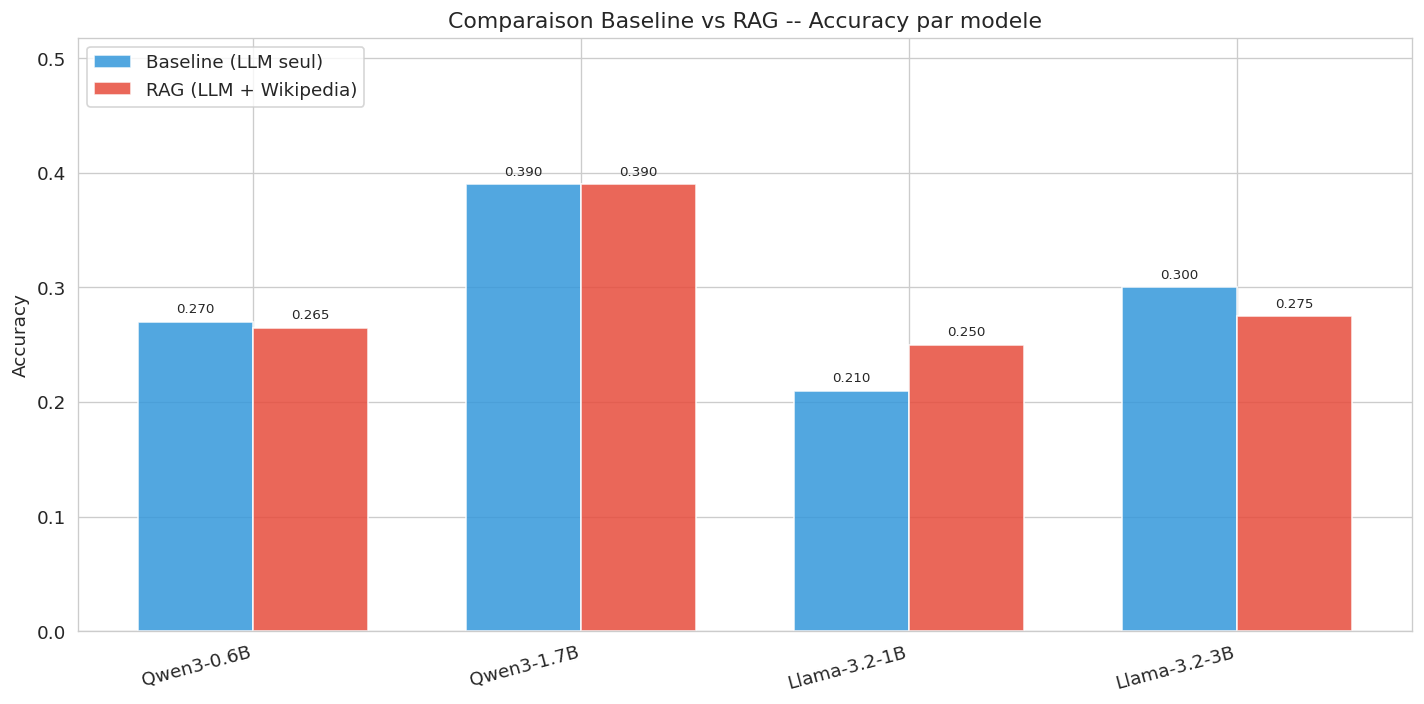

Figure sauvegardee : results/fig1_accuracy_baseline_vs_rag.png


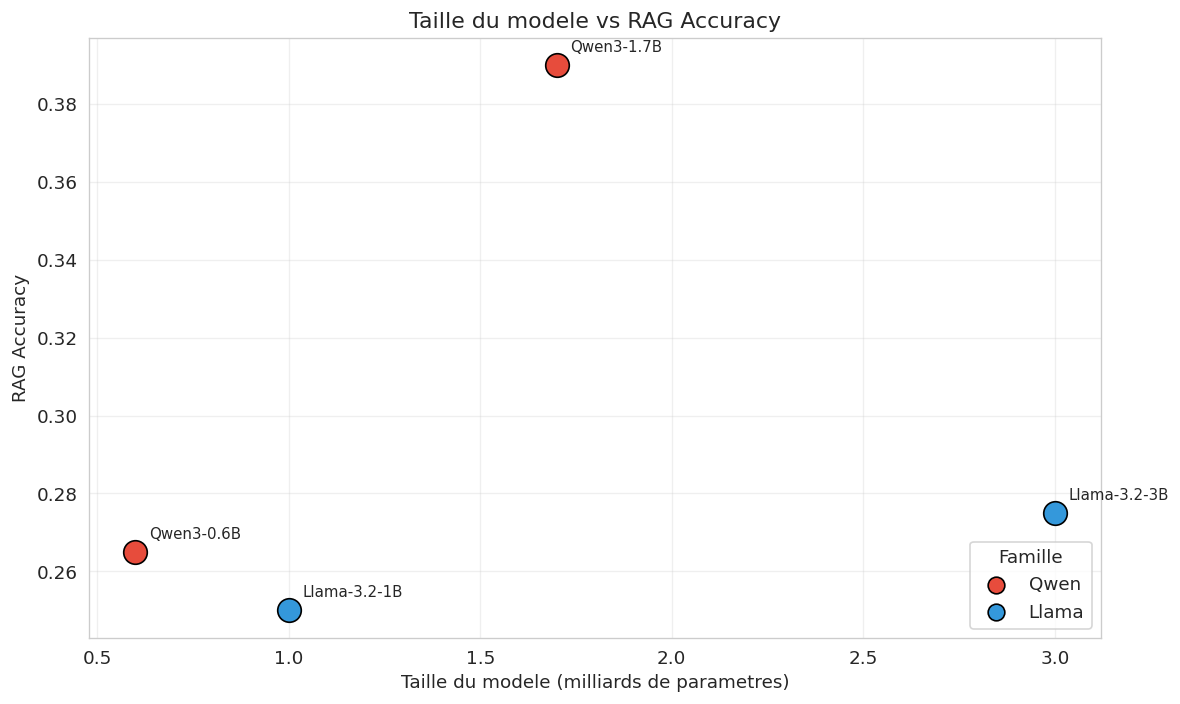

Figure sauvegardee : results/fig2_size_vs_accuracy.png


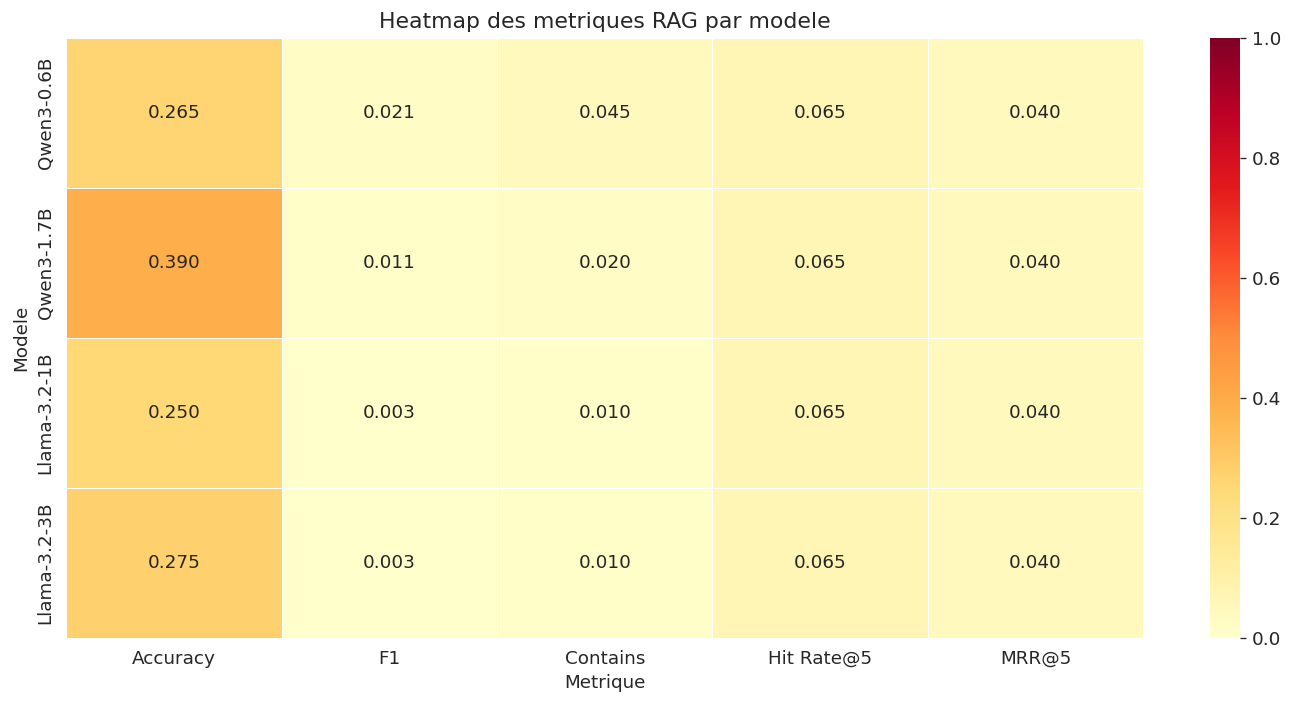

Figure sauvegardee : results/fig3_heatmap_metrics.png


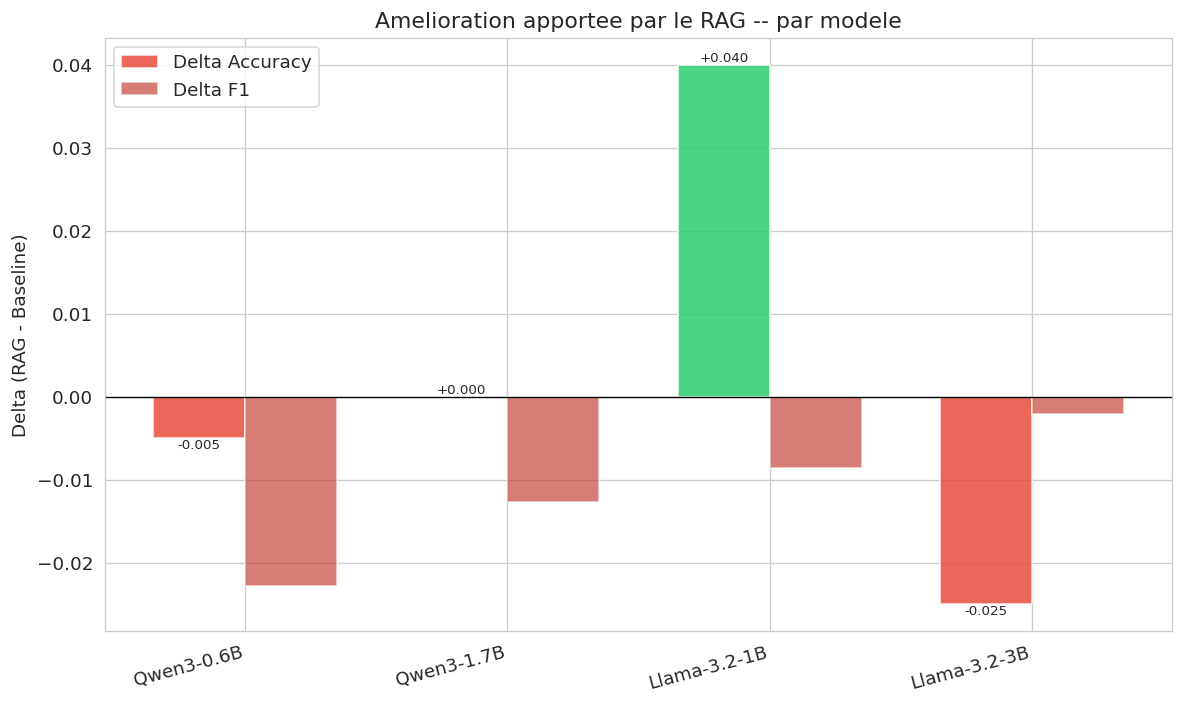

Figure sauvegardee : results/fig4_improvement_delta.png


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

model_names = df_comparison['Modele'].tolist()
n_models = len(model_names)

# ======================================================================
# Figure 1 : Accuracy Baseline vs RAG par modele (barres groupees)
# ======================================================================
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(n_models)
width = 0.35

baseline_accs = np.asarray(df_comparison['Baseline Acc'].values, dtype=float)
rag_accs = np.asarray(df_comparison['RAG Acc'].values, dtype=float)

bars1 = ax.bar(x - width/2, baseline_accs, width, label='Baseline (LLM seul)',
               color='#3498db', alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + width/2, rag_accs, width, label='RAG (LLM + Wikipedia)',
               color='#e74c3c', alpha=0.85, edgecolor='white')

for bar in bars1:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h + 0.005,
            f'{h:.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h + 0.005,
            f'{h:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_ylabel('Accuracy')
ax.set_title('Comparaison Baseline vs RAG -- Accuracy par modele')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.legend(loc='upper left')
ax.set_ylim(0, max(max(baseline_accs), max(rag_accs)) * 1.2 + 0.05)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/fig1_accuracy_baseline_vs_rag.png', bbox_inches='tight')
plt.show()
print(f"Figure sauvegardee : {RESULTS_DIR}/fig1_accuracy_baseline_vs_rag.png")

# ======================================================================
# Figure 2 : Taille du modele vs RAG Accuracy (nuage de points)
# ======================================================================
fig, ax = plt.subplots(figsize=(10, 6))

family_colors = {'Qwen': '#e74c3c', 'Llama': '#3498db', 'Mistral': '#2ecc71'}

for _, row in df_comparison.iterrows():
    color = family_colors.get(row['Famille'], '#95a5a6')
    ax.scatter(row['Taille (B)'], row['RAG Acc'], s=200, c=color,
               edgecolors='black', linewidth=1, zorder=5)
    ax.annotate(row['Modele'], (row['Taille (B)'], row['RAG Acc']),
                textcoords='offset points', xytext=(8, 8), fontsize=9)

# Legende par famille
for family, color in family_colors.items():
    if family in df_comparison['Famille'].values:
        ax.scatter([], [], c=color, s=100, edgecolors='black', linewidth=1, label=family)
ax.legend(title='Famille', loc='lower right')

ax.set_xlabel('Taille du modele (milliards de parametres)')
ax.set_ylabel('RAG Accuracy')
ax.set_title('Taille du modele vs RAG Accuracy')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/fig2_size_vs_accuracy.png', bbox_inches='tight')
plt.show()
print(f"Figure sauvegardee : {RESULTS_DIR}/fig2_size_vs_accuracy.png")

# ======================================================================
# Figure 3 : Heatmap -- Modeles x Metriques
# ======================================================================
fig, ax = plt.subplots(figsize=(12, 6))

heatmap_data = df_comparison[['Modele', 'RAG Acc', 'RAG F1', 'RAG Contains',
                               'Hit Rate@5', 'MRR@5']].copy()
heatmap_data = heatmap_data.set_index('Modele')
heatmap_data.columns = ['Accuracy', 'F1', 'Contains', 'Hit Rate@5', 'MRR@5']

sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, vmin=0, vmax=1)
ax.set_title('Heatmap des metriques RAG par modele')
ax.set_ylabel('Modele')
ax.set_xlabel('Metrique')

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/fig3_heatmap_metrics.png', bbox_inches='tight')
plt.show()
print(f"Figure sauvegardee : {RESULTS_DIR}/fig3_heatmap_metrics.png")

# ======================================================================
# Figure 4 : Amelioration (delta) par modele
# ======================================================================
fig, ax = plt.subplots(figsize=(10, 6))

deltas_acc = np.asarray(df_comparison['Delta Acc'].values, dtype=float)
deltas_f1 = np.asarray(df_comparison['Delta F1'].values, dtype=float)

x = np.arange(n_models)
width = 0.35

colors_acc = ['#2ecc71' if d >= 0 else '#e74c3c' for d in deltas_acc]
colors_f1 = ['#27ae60' if d >= 0 else '#c0392b' for d in deltas_f1]

bars1 = ax.bar(x - width/2, deltas_acc, width, label='Delta Accuracy',
               color=colors_acc, alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + width/2, deltas_f1, width, label='Delta F1',
               color=colors_f1, alpha=0.65, edgecolor='white')

for bar in bars1:
    h = bar.get_height()
    va = 'bottom' if h >= 0 else 'top'
    ax.text(bar.get_x() + bar.get_width()/2., h, f'{h:+.3f}',
            ha='center', va=va, fontsize=8)

ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_ylabel('Delta (RAG - Baseline)')
ax.set_title('Amelioration apportee par le RAG -- par modele')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/fig4_improvement_delta.png', bbox_inches='tight')
plt.show()
print(f"Figure sauvegardee : {RESULTS_DIR}/fig4_improvement_delta.png")

## Etape 7 -- Analyse des facteurs

In [ ]:
# == Facteur 1 : Taille du modele =============================================
print("=" * 60)
print("ANALYSE -- Facteur : Taille du modele")
print("=" * 60)
for _, row in df_comparison.sort_values('Taille (B)').iterrows():
    print(f"  {row['Modele']:20s} ({row['Taille (B)']:.1f}B) : "
          f"Baseline Acc={row['Baseline Acc']:.4f}, "
          f"RAG Acc={row['RAG Acc']:.4f}")

# Correlation taille vs accuracy
if len(df_comparison) >= 3:
    from scipy import stats
    corr, p_val = stats.pearsonr(df_comparison['Taille (B)'], df_comparison['RAG Acc'])
    print(f"\n  Correlation (Pearson) Taille vs RAG Acc : r={corr:.4f}, p={p_val:.4f}")
    if p_val < 0.05:
        print(f"  --> Correlation significative (p < 0.05)")
    else:
        print(f"  --> Correlation non significative (p >= 0.05)")

# == Facteur 2 : Famille de modele ============================================
print(f"\n{'='*60}")
print("ANALYSE -- Facteur : Famille de modele")
print("=" * 60)
family_means = df_comparison.groupby('Famille').agg({
    'RAG Acc': 'mean',
    'RAG F1': 'mean',
    'Baseline Acc': 'mean',
    'Delta Acc': 'mean',
    'Taille (B)': 'mean'
}).round(4)
print(family_means.to_string())

print(f"\n  Meilleure famille (RAG Acc moyenne) : {family_means['RAG Acc'].idxmax()} "
      f"({family_means['RAG Acc'].max():.4f})")

# == Facteur 3 : Impact du RAG par modele =====================================
print(f"\n{'='*60}")
print("ANALYSE -- Facteur : Impact du RAG")
print("=" * 60)
for _, row in df_comparison.iterrows():
    delta = row['Delta Acc']
    if delta > 0.02:
        impact = "POSITIF"
    elif delta < -0.02:
        impact = "NEGATIF"
    else:
        impact = "NEUTRE"
    print(f"  {row['Modele']:20s} : delta={row['Delta Acc']:+.4f} ({impact})")

avg_delta = df_comparison['Delta Acc'].mean()
print(f"\n  Impact moyen du RAG sur l'Accuracy : {avg_delta:+.4f}")
n_positive = (df_comparison['Delta Acc'] > 0).sum()
print(f"  Modeles ameliores par le RAG : {n_positive}/{len(df_comparison)}")

# == Facteur 4 : Latence ======================================================
print(f"\n{'='*60}")
print("ANALYSE -- Facteur : Latence (temps/question)")
print("=" * 60)
for _, row in df_comparison.iterrows():
    time_baseline = row['Temps Baseline (s)'] / MAX_QUESTIONS
    time_rag = row['Temps RAG (s)'] / MAX_QUESTIONS
    overhead = time_rag - time_baseline
    print(f"  {row['Modele']:20s} : "
          f"Baseline={time_baseline:.2f}s/q, "
          f"RAG={time_rag:.2f}s/q, "
          f"Overhead={overhead:+.2f}s/q")

# == Facteur 5 : Efficacite (Accuracy / Taille) ===============================
print(f"\n{'='*60}")
print("ANALYSE -- Facteur : Efficacite (RAG Acc / Taille)")
print("=" * 60)
df_comparison['Efficacite'] = df_comparison['RAG Acc'] / df_comparison['Taille (B)']
for _, row in df_comparison.sort_values('Efficacite', ascending=False).iterrows():
    print(f"  {row['Modele']:20s} : Efficacite={row['Efficacite']:.4f} "
          f"(Acc={row['RAG Acc']:.4f} / {row['Taille (B)']:.1f}B)")

ANALYSE -- Facteur : Taille du modele
  Qwen3-0.6B           (0.6B) : Baseline Acc=0.2700, RAG Acc=0.2900
  Llama-3.2-1B         (1.0B) : Baseline Acc=0.3200, RAG Acc=0.2550
  Qwen3-1.7B           (1.7B) : Baseline Acc=0.4000, RAG Acc=0.3550
  Llama-3.2-3B         (3.0B) : Baseline Acc=0.2750, RAG Acc=0.2750

  Correlation (Pearson) Taille vs RAG Acc : r=0.0503, p=0.9497
  --> Correlation non significative (p >= 0.05)

ANALYSE -- Facteur : Famille de modele
         RAG Acc  RAG F1  Baseline Acc  Delta Acc  Taille (B)
Famille                                                      
Llama     0.2650  0.0068        0.2975    -0.0325        2.00
Qwen      0.3225  0.0132        0.3350    -0.0125        1.15

  Meilleure famille (RAG Acc moyenne) : Qwen (0.3225)

ANALYSE -- Facteur : Impact du RAG
  Qwen3-0.6B           : delta=+0.0200 (NEUTRE)
  Qwen3-1.7B           : delta=-0.0450 (NEGATIF)
  Llama-3.2-1B         : delta=-0.0650 (NEGATIF)
  Llama-3.2-3B         : delta=+0.0000 (NEUTRE)

  Im

## Etape 8 -- Analyse qualitative

Examen des cas ou les modeles divergent dans leurs predictions,
pour comprendre les forces et faiblesses de chaque LLM.

In [ ]:
# == Analyse des desaccords entre modeles ======================================
print("=" * 60)
print("ANALYSE QUALITATIVE -- Desaccords entre modeles")
print("=" * 60)

# Collecter les predictions RAG de chaque modele
model_predictions = {}
for name, res in all_results.items():
    if 'error' in res:
        continue
    model_predictions[name] = res['predictions']['rag_letters']

valid_models = list(model_predictions.keys())

if len(valid_models) >= 2:
    # Trouver les questions ou les modeles ne sont pas d'accord
    disagreements = []
    for i in range(MAX_QUESTIONS):
        preds_i = {m: model_predictions[m][i] for m in valid_models}
        unique_preds = set(preds_i.values())
        if len(unique_preds) > 1:
            correct = correct_letters[i]
            n_correct = sum(1 for p in preds_i.values() if p.upper() == correct.upper())
            disagreements.append({
                'index': i,
                'question': questions[i][:200],
                'correct': correct,
                'predictions': preds_i,
                'n_correct': n_correct,
            })

    print(f"\n  Nombre de desaccords : {len(disagreements)} / {MAX_QUESTIONS} "
          f"({len(disagreements)/MAX_QUESTIONS*100:.1f}%)")
    print(f"  Nombre d'accords unanimes : {MAX_QUESTIONS - len(disagreements)}")

    # Montrer les 10 premiers desaccords
    print(f"\n  --- Exemples de desaccords ---")
    for j, d in enumerate(disagreements[:10]):
        print(f"\n  Question {d['index']} : {d['question']}")
        print(f"    Reponse correcte : {d['correct']}")
        for m, p in d['predictions'].items():
            status = "OK" if p.upper() == d['correct'].upper() else "FAUX"
            print(f"    {m:20s} : {p} ({status})")

    # Matrice d'accord entre modeles
    print(f"\n  --- Matrice d'accord (proportion) ---")
    if len(valid_models) >= 2:
        agreement_matrix = {}
        for m1 in valid_models:
            agreement_matrix[m1] = {}
            for m2 in valid_models:
                agreement = sum(
                    1 for i in range(MAX_QUESTIONS)
                    if model_predictions[m1][i].upper() == model_predictions[m2][i].upper()
                ) / MAX_QUESTIONS
                agreement_matrix[m1][m2] = agreement

        df_agreement = pd.DataFrame(agreement_matrix)
        print(df_agreement.round(3).to_string())

    # Vote majoritaire
    print(f"\n  --- Vote majoritaire ---")
    majority_correct = 0
    for i in range(MAX_QUESTIONS):
        preds_i = [model_predictions[m][i].upper() for m in valid_models]
        vote_counts = Counter(preds_i)
        majority_vote = vote_counts.most_common(1)[0][0]
        if majority_vote == correct_letters[i].upper():
            majority_correct += 1
    majority_acc = majority_correct / MAX_QUESTIONS
    print(f"  Accuracy du vote majoritaire : {majority_acc:.4f}")
    print(f"  (compare au meilleur modele individuel : {df_comparison['RAG Acc'].max():.4f})")

else:
    print("  Pas assez de modeles valides pour l'analyse qualitative.")

ANALYSE QUALITATIVE -- Desaccords entre modeles

  Nombre de desaccords : 188 / 200 (94.0%)
  Nombre d'accords unanimes : 12

  --- Exemples de desaccords ---

  Question 0 : While the Tiangong-1 and Shenzhou-9 combination is in orbit, the celestial system it forms with the celestial body it orbits is of the same level as which of the following? (　　)
    Reponse correcte : D
    Qwen3-0.6B           : A (FAUX)
    Qwen3-1.7B           : C (FAUX)
    Llama-3.2-1B         : C (FAUX)
    Llama-3.2-3B         : C (FAUX)

  Question 1 : When Tiangong-1 and Shenzhou-9 successfully docked, which city had the longest daylight hours? (　　)
    Reponse correcte : A
    Qwen3-0.6B           : A (OK)
    Qwen3-1.7B           : A (OK)
    Llama-3.2-1B         : A (OK)
    Llama-3.2-3B         : B (FAUX)

  Question 2 : Which of the following statements about the Tiangong-1 and Shenzhou-9 combination during its in-orbit operation is incorrect? (　　)
    Reponse correcte : B
    Qwen3-0.6B           : 

## Etape 9 -- Sauvegarde

In [13]:
import json

# == Sauvegarde JSON -- Tous les resultats =====================================
# Creer une version serialisable (sans les listes de predictions)
results_json = {}
for name, res in all_results.items():
    if 'error' in res:
        results_json[name] = res
        continue
    results_json[name] = {
        'model_id': res['model_id'],
        'family': res['family'],
        'size_B': res['size_B'],
        'baseline': res['baseline'],
        'rag': res['rag'],
        'retrieval': res['retrieval'],
        'improvement': res['improvement'],
    }

# Ajouter les metadonnees
output_json = {
    'phase': '2a',
    'description': 'Comparaison Multi-LLMs sur GeoSQA avec RAG',
    'config': CONFIG,
    'n_questions': MAX_QUESTIONS,
    'n_models': len(MODELS),
    'results': results_json,
}

json_path = f'{RESULTS_DIR}/phase2a_all_results.json'
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(output_json, f, indent=2, ensure_ascii=False)
print(f"Resultats JSON sauvegardes : {json_path}")

# == Sauvegarde CSV -- Tableau comparatif ======================================
csv_path = f'{RESULTS_DIR}/phase2a_comparison.csv'
df_comparison.to_csv(csv_path, index=False, encoding='utf-8-sig')
print(f"Tableau comparatif CSV sauvegarde : {csv_path}")

# == Sauvegarde CSV -- Predictions detaillees ==================================
pred_rows = []
for i in range(MAX_QUESTIONS):
    row = {
        'index': i,
        'question': questions[i][:500],
        'correct_letter': correct_letters[i],
        'correct_text': correct_texts[i][:200],
    }
    for name, res in all_results.items():
        if 'error' in res:
            continue
        row[f'{name}_baseline'] = res['predictions']['baseline_letters'][i]
        row[f'{name}_rag'] = res['predictions']['rag_letters'][i]
        row[f'{name}_baseline_ok'] = 1 if res['predictions']['baseline_letters'][i].upper() == correct_letters[i].upper() else 0
        row[f'{name}_rag_ok'] = 1 if res['predictions']['rag_letters'][i].upper() == correct_letters[i].upper() else 0
    pred_rows.append(row)

df_predictions = pd.DataFrame(pred_rows)
pred_csv_path = f'{RESULTS_DIR}/phase2a_predictions.csv'
df_predictions.to_csv(pred_csv_path, index=False, encoding='utf-8-sig')
print(f"Predictions detaillees CSV sauvegardees : {pred_csv_path}")

# == Affichage resume ==========================================================
print(f"\n{'='*60}")
print(f"FICHIERS GENERES")
print(f"{'='*60}")
print(f"  {json_path}")
print(f"  {csv_path}")
print(f"  {pred_csv_path}")
print(f"  {RESULTS_DIR}/fig1_accuracy_baseline_vs_rag.png")
print(f"  {RESULTS_DIR}/fig2_size_vs_accuracy.png")
print(f"  {RESULTS_DIR}/fig3_heatmap_metrics.png")
print(f"  {RESULTS_DIR}/fig4_improvement_delta.png")

# == Sauvegarde optionnelle sur Google Drive ===================================
SAVE_TO_DRIVE = True

if SAVE_TO_DRIVE:
    try:
        from google.colab import drive
        drive.mount('/content/drive')

        import shutil
        drive_dest = '/content/drive/MyDrive/GeoR2LLMs/Phase2a/results'
        os.makedirs(drive_dest, exist_ok=True)

        for fname in os.listdir(RESULTS_DIR):
            src = os.path.join(RESULTS_DIR, fname)
            dst = os.path.join(drive_dest, fname)
            shutil.copy2(src, dst)
            print(f"Copie : {dst}")

        print(f"\nTous les resultats ont ete copies sur Google Drive : {drive_dest}")

    except ImportError:
        print("\nGoogle Drive non disponible (environnement non-Colab).")
    except Exception as e:
        print(f"\nErreur lors de la sauvegarde sur Google Drive : {e}")

Resultats JSON sauvegardes : results/phase2a_all_results.json
Tableau comparatif CSV sauvegarde : results/phase2a_comparison.csv
Predictions detaillees CSV sauvegardees : results/phase2a_predictions.csv

FICHIERS GENERES
  results/phase2a_all_results.json
  results/phase2a_comparison.csv
  results/phase2a_predictions.csv
  results/fig1_accuracy_baseline_vs_rag.png
  results/fig2_size_vs_accuracy.png
  results/fig3_heatmap_metrics.png
  results/fig4_improvement_delta.png
Mounted at /content/drive
Copie : /content/drive/MyDrive/GeoR2LLMs/Phase2a/results/phase2a_comparison.csv
Copie : /content/drive/MyDrive/GeoR2LLMs/Phase2a/results/phase2a_predictions.csv
Copie : /content/drive/MyDrive/GeoR2LLMs/Phase2a/results/fig1_accuracy_baseline_vs_rag.png
Copie : /content/drive/MyDrive/GeoR2LLMs/Phase2a/results/fig3_heatmap_metrics.png
Copie : /content/drive/MyDrive/GeoR2LLMs/Phase2a/results/phase2a_all_results.json
Copie : /content/drive/MyDrive/GeoR2LLMs/Phase2a/results/fig2_size_vs_accuracy.png


## Resume Phase 2a — GeoSQA

### Classement des modeles (RAG Accuracy)

| Rang | Modele | RAG Accuracy | Delta vs Baseline |
|------|--------|-------------|-------------------|
| 1 | Qwen3-1.7B | 0.3900 | +0.0000 |
| 2 | Llama-3.2-3B | 0.2750 | -0.0250 |
| 3 | Qwen3-0.6B | 0.2650 | -0.0050 |
| 4 | Llama-3.2-1B | 0.2500 | +0.0400 |
| 5 | Ministral-3B | ERREUR | Incompatible avec AutoModelForCausalLM |

### Conclusions
1. **Qwen3-1.7B domine nettement** : Avec une RAG Accuracy de 0.3900, il devance largement le deuxieme (Llama-3.2-3B a 0.2750). Sa Baseline (0.3900) est egalement la meilleure, ce qui suggere que la qualite intrinseque du modele est le facteur determinant.
2. **Le RAG a un impact quasi-nul voire negatif** : Impact moyen = +0.0025. Seul Llama-3.2-1B beneficie du RAG (+0.04), les autres stagnent ou regressent. Le contexte Wikipedia FR est inadapte aux questions GeoSQA (traduites du chinois).
3. **Retrieval quasi-inexistant** : Hit Rate@5 = 0.065, MRR@5 = 0.040 — identiques pour tous les modeles (meme retriever). Le mismatch linguistique (questions EN traduites du chinois, corpus FR) limite la pertinence des documents recuperes.
4. **Pas de correlation taille-performance** : r = 0.05, p = 0.95. Llama-3.2-3B (3B) ne surpasse pas Qwen3-0.6B (0.6B). La famille du modele compte plus que sa taille.
5. **Vote majoritaire sous-performant** : Accuracy 0.3150, inferieure au meilleur modele (0.3900). Le taux de desaccord de 94% montre que les modeles font des erreurs non-correlees et de nature differente.
6. **Exact Match a zero** : Aucun modele ne genere de reponse textuellement identique a la verite terrain (EM = 0.0 pour tous). Les modeles repondent dans un format different de la reference.
7. **Ministral-3B incompatible** : Le modele `Ministral-3-3B-Instruct-2512` utilise `Mistral3Config` non supporte par `AutoModelForCausalLM`.

### Prochaines etapes
- **Phase 2b** : Evaluation sur GKMC (Geographic Knowledge Multiple Choice)
- **Phase 2c** : Evaluation sur Tourism-QA
- **Phase 2d** : Analyse factorielle croisee (modeles x datasets x metriques)